Ian Pope (700717419) CS5720 HW2

Q1. Implementing an RNN for Text Generation

In [1]:
import tensorflow as tf
import numpy as np
import os

In [2]:
#Get the shakespeare dataset from tensorflow
path_to_file = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

#Open the file
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Convert the text to a sequence of characters

#Get all possible chars
chars = sorted(set(text))

#Create the mappings of chars and nums
char_to_num = {char: num for num, char in enumerate(chars)}
num_to_char = {num: char for num, char in enumerate(chars)}

#Encode the text using the mapping
encoded_text = np.array([char_to_num[c] for c in text])

In [4]:
#Prepare our training data

#Length of each training sequence
seq_length = 100

#Create a TensorFlow dataset
char_dataset = tf.data.Dataset.from_tensor_slices(encoded_text)

#Create sequences of length seq_length + 1
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(sequence):
    input_text = sequence[:-1]
    target_text = sequence[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

#Create our different batches
BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = (
    dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.experimental.AUTOTUNE)
)

print("Dataset prepared")


Dataset prepared


In [5]:
#Build the RNN using LSTM
num_chars = len(chars)
embedding_dims = 256
rnn_units = 512

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(num_chars, embedding_dims),
    tf.keras.layers.LSTM(rnn_units, return_sequences=True),
    tf.keras.layers.Dense(num_chars)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Define the loss function and compile the model
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer='adam', loss=loss)

In [17]:
#Fit the model
num_epochs = 20
history = model.fit(dataset, epochs=num_epochs)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 1.3303
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 1.3112
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.2925
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 1.2767
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.2624
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 1.2464
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 1.2337
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 1.2195
Epoch 9/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 1.2068
Epoch 10/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 1.1935
Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.1808
Epoch 12/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.1680
Epoch 13/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.1558
Epoch 14/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.1430
Epoch 15/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 10

In [15]:
#Create a function that lets us input a string and generate off of that
def generate_text(model, start_string, num_generate=300, temperature=1.0):

    input_eval = [char_to_num[s] for s in start_string]
    generated_text = start_string

    for i in range(num_generate):

        #Give the model everything generated so far
        input_tensor = tf.expand_dims(input_eval, 0)

        predictions = model(input_tensor)

        #Get prediction for the final character
        predictions = predictions[:, -1, :]

        #Apply Temperature
        predictions = predictions / temperature

        #Select next character
        predicted_id = tf.random.categorical(predictions, num_samples=1)[0, 0].numpy()

        #Add character
        generated_text += num_to_char[predicted_id]

        #Add it to the input for the next prediction
        input_eval.append(predicted_id)

    return generated_text

In [19]:
#Use function to create new text with temp = 1
generated = generate_text(model, start_string="ROMEO:", num_generate=300, temperature=1.0)
print(generated)

ROMEO:
The next: though all the profane extorth her, shall
Was possible: then, Signior Luddic, left me, if
The triumph of all hours fine delivery pace.
Good faith purpose! But Heavy matester?

MARCIUS:
I thought counsel the fire left the hollow's grave.

Wordshard:
An if they have said before devoury like


In [20]:
#Use function to create new text with temp = 1.5
generated = generate_text(model, start_string="ROMEO:", num_generate=300, temperature=1.5)
print(generated)

ROMEO:
By these's that hasty ency, on
Of what spurst-charges 'trea, oll dates il
Pitcan.
'Coundon's lahm indeed, proud Ay; for
Jehemise you; for he swears lost done work burina.
ANa ruinalus would not poxe thou hast,
is indornted seized itsmen; for I mo, Raginu:
I warrant yourself aus King Edward's crush



In [21]:
#Use function to create new text with temp = 0.2
generated = generate_text(model, start_string="ROMEO:", num_generate=300, temperature=0.2)
print(generated)

ROMEO:
The gods shall not be the dear as the seas,
That lie the lady of the field of company.

GLOUCESTER:
Then give me leave to see the crown to the soul,
Who have been as a strange abused as they
are the strength and the boldness of the duke and looks
More than the sea that she shall be so far
That have


5. Explain the role of temperature scaling in text generation and its effect on randomness  
(This answer is also in the assignment document)  
The role of temperature scaling is to provide how much randomness should be used for the prediction of the next value by flattening the odds between values. With a lower value for temperature, the returned values are less random and more consistent with actual odds calculated while a higher temperature will provide more randomness by flattening the odds of every prediction, incresing the likelihood of selecting something that is not the top option.

Q2: Sentiment Classification Using RNN

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
#Load the imdb dataset

#Limit the number of words
num_words = 10000

#Data is already tokenized
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words = num_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Set max length of entry and pad entries to match
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [4]:
#Create the model using a LSTM RNN
model = tf.keras.Sequential([

    #Add Embedding Layer
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=128),

    #LSTM layer
    tf.keras.layers.LSTM(128),

    #Output probability of positive sentiment
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

#Compile Model
model.compile( optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Train and fit the model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.7641 - loss: 0.4772 - val_accuracy: 0.8446 - val_loss: 0.3668
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8790 - loss: 0.2980 - val_accuracy: 0.8538 - val_loss: 0.3579
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9105 - loss: 0.2256 - val_accuracy: 0.8636 - val_loss: 0.3330
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9463 - loss: 0.1488 - val_accuracy: 0.8554 - val_loss: 0.3882
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9642 - loss: 0.1040 - val_accuracy: 0.8436 - val_loss: 0.4659


In [6]:
#Make prediction for the test data
y_probability = model.predict(x_test)

y_pred = (y_probability >= 0.5).astype(int).flatten()


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


[[10014  2486]
 [ 1452 11048]]


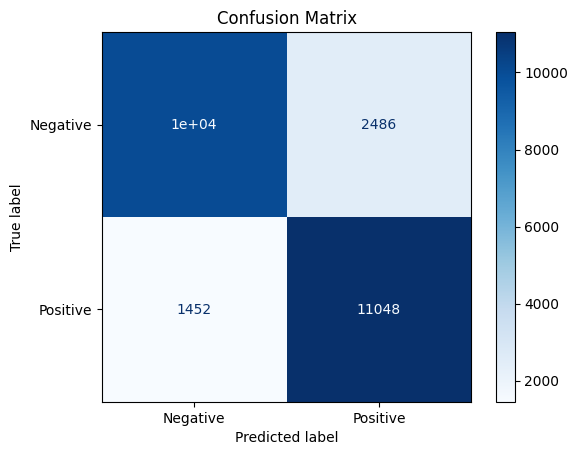

In [7]:
#Calculate and display confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [8]:
#Get the test accuracy
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8425 - loss: 0.4648
Test Accuracy: 0.8424800038337708


In [9]:
#Classification Report with Precission, recall, and f1
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))


              precision    recall  f1-score   support

    Negative       0.87      0.80      0.84     12500
    Positive       0.82      0.88      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



5. Interpret why precision-recall tradeoff is important in sentiment classification
(This answer is also in the assignment document)  
The precision and recall tradeoff is important because you need to balance the two metrics depending on the problem you are trying to solve. You can balance with high precision to make sure that you are confident on the sentiment you predict for a certain class or for high recall where you are detecting most of the class, even if there are some false postives.

Q3: Convolution Operations with Different Parameters

In [1]:
#I am adding all of these redundant imports because I keep switching CPU/GPU runtimes in Colab
import numpy as np
import tensorflow as tf

In [7]:
#Initialize input matrix and kernel
input_matrix = np.array([
    [1,  2,  3,  4,  5],
    [6,  7,  8,  9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
], dtype=np.float32)

kernel = np.array([
    [0,  1,  0],
    [1, -4,  1],
    [0,  1,  0]
], dtype=np.float32)

#Convert to tensorflow tensors
input_tensor = tf.constant(input_matrix)
input_tensor = tf.reshape(input_tensor, [1, 5, 5, 1])

kernel_tensor = tf.constant(kernel)
kernel_tensor = tf.reshape(kernel_tensor, [3, 3, 1, 1])

In [8]:
#Stride = 1, Padding = VALID
output_valid_s1 = tf.nn.conv2d(input_tensor, kernel_tensor, strides=[1, 1, 1, 1], padding="VALID")

print("Stride = 1, Padding = VALID")
print(output_valid_s1.numpy().squeeze())

Stride = 1, Padding = VALID
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [9]:
#Stride = 1, Padding = SAME
output_same_s1 = tf.nn.conv2d(input_tensor, kernel_tensor, strides=[1, 1, 1, 1], padding="SAME")

print("Stride = 1, Padding = SAME")
print(output_same_s1.numpy().squeeze())

Stride = 1, Padding = SAME
[[  4.   3.   2.   1.  -6.]
 [ -5.   0.   0.   0. -11.]
 [-10.   0.   0.   0. -16.]
 [-15.   0.   0.   0. -21.]
 [-46. -27. -28. -29. -56.]]


In [10]:
#Stride = 2, Padding = VALID
output_valid_s2 = tf.nn.conv2d(input_tensor, kernel_tensor, strides=[1, 2, 2, 1], padding="VALID")

print("Stride = 2, Padding = VALID")
print(output_valid_s2.numpy().squeeze())

Stride = 2, Padding = VALID
[[0. 0.]
 [0. 0.]]


In [11]:
#Stride = 2, Padding = SAME
output_same_s2 = tf.nn.conv2d(input_tensor, kernel_tensor, strides=[1, 2, 2, 1], padding="SAME")

print("Stride = 2, Padding = SAME")
print(output_same_s2.numpy().squeeze())

Stride = 2, Padding = SAME
[[  4.   2.  -6.]
 [-10.   0. -16.]
 [-46. -28. -56.]]


Q4: CNN Feature Extraction with Filters and Pooling

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

In [15]:
#Import an image from skimage
image = data.astronaut()

#Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

In [21]:
#Define Sobel filters
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=np.float32)

In [28]:
#Apply filters to the image
edge_x = cv2.filter2D(gray, -1, sobel_x)
edge_y = cv2.filter2D(gray, -1, sobel_y)

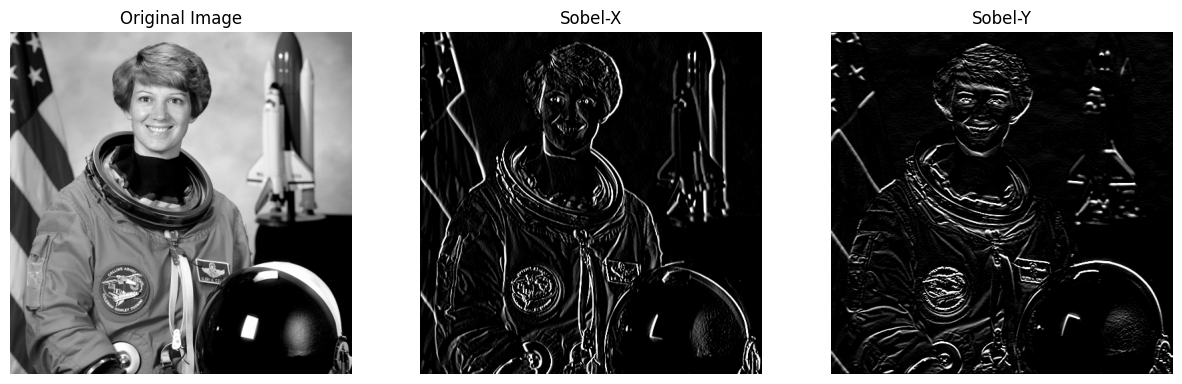

In [30]:
#Plot the original and sobel filtered images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edge_x, cmap="gray")
plt.title("Sobel-X")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edge_y, cmap="gray")
plt.title("Sobel-Y")
plt.axis("off")

plt.show()


In [31]:
#Max pooling and average pooling
#Create a random 4x4 matrix
input_matrix = np.random.randint(1, 10, size=(4, 4)).astype(np.float32)

print("Original Matrix:")
print(input_matrix)

#Convert to tensorflow tensor
input_tensor = tf.constant(input_matrix)
input_tensor = tf.reshape(input_tensor, [1, 4, 4, 1])

Original Matrix:
[[9. 3. 1. 5.]
 [3. 1. 3. 1.]
 [3. 3. 7. 3.]
 [1. 6. 9. 3.]]


In [35]:
#Apply max pooling
max_pool = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2)
max_output = max_pool(input_tensor)

print("Max Pooled Matrix:")
print(max_output.numpy().squeeze())

Max Pooled Matrix:
[[9. 5.]
 [6. 9.]]


In [36]:
#Apply average pooling
avg_pool = tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2)
avg_output = avg_pool(input_tensor)

print("Average Pooled Matrix:")
print(avg_output.numpy().squeeze())

Average Pooled Matrix:
[[4.   2.5 ]
 [3.25 5.5 ]]


In [37]:
#All matrices
print("Original Matrix:")
print(input_matrix)
print("Max Pooled Matrix:")
print(max_output.numpy().squeeze())
print("Average Pooled Matrix:")
print(avg_output.numpy().squeeze())

Original Matrix:
[[9. 3. 1. 5.]
 [3. 1. 3. 1.]
 [3. 3. 7. 3.]
 [1. 6. 9. 3.]]
Max Pooled Matrix:
[[9. 5.]
 [6. 9.]]
Average Pooled Matrix:
[[4.   2.5 ]
 [3.25 5.5 ]]


Q5: Implementing and Comparing CNN Architectures

In [38]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [39]:
#Implement AlexNet Architecture
alexnet = models.Sequential([

    #Conv layer 1
    layers.Conv2D(96, kernel_size=(11, 11), strides=4, activation="relu", input_shape=(224, 224, 3)),

    #Max pooling 1
    layers.MaxPooling2D(pool_size=(3, 3), strides=2),

    #Conv layer 2
    layers.Conv2D(256, kernel_size=(5, 5), activation="relu"),

    #Max pooling 2
    layers.MaxPooling2D( pool_size=(3, 3), strides=2),

    #Conv layer 3
    layers.Conv2D(384, kernel_size=(3, 3), activation="relu"),

    #Conv layer 4
    layers.Conv2D(384, kernel_size=(3, 3), activation="relu"),

    #Conv layer 5
    layers.Conv2D(256, kernel_size=(3, 3), activation="relu"),

    #Max pooling 3
    layers.MaxPooling2D(pool_size=(3, 3), strides=2),

    #Flatten
    layers.Flatten(),

    #Fully connected layer
    layers.Dense(4096, activation="relu"),

    #Dropout
    layers.Dropout(0.5),

    #Fully connected layer
    layers.Dense(4096, activation="relu"),

    #Dropout
    layers.Dropout(0.5),

    #Output
    layers.Dense(10, activation="softmax")
])

alexnet.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,622,154 (82.48 MB)

 Trainable params: 21,622,154 (82.48 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#Implement a Residual Block and ResNet
#Implement the residual block function
def residual_block(input_tensor, filters=64):
  x = layers.Conv2D(filters, kernel_size=(3, 3), activation="relu", padding="same")(input_tensor)
  x = layers.Conv2D(filters, kernel_size=(3, 3), padding="same")(x)

  #Skip Connection
  x = layers.Add()([x, input_tensor])

  #Perform ReLU only after addition
  x = layers.ReLU()(x)

  return x

In [41]:
#Build a ResNet like model
inputs = layers.Input(shape=(224, 224, 3))

#Initial Conv layer
x = layers.Conv2D(64, kernel_size=(7, 7), strides=2, activation="relu", padding="same")(inputs)

#Two residual blocks
x = residual_block(x, filters=64)
x = residual_block(x, filters=64)

#Flatten
x = layers.Flatten()(x)

#Fully connected layer
x = layers.Dense(128, activation="relu")(x)

#Output layer
outputs = layers.Dense(10, activation="softmax")(x)

#Create the model
resnet = models.Model(inputs=inputs, outputs=outputs)

resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │      9,472 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ conv2d_7[0][0],   │
│                     │ 64)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 112, 112,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 112, 112,  │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 112, 112,  │          0 │ conv2d_9[0][0],   │
│                     │ 64)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 802816)    │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │ 102,760,5… │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │      1,290 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 102,919,050 (392.61 MB)

 Trainable params: 102,919,050 (392.61 MB)

 Non-trainable params: 0 (0.00 B)